# SVM (Support Vector Machine)

SVM is a classification algorithm that finds the best possible boundary line (or plane, in higher dimensions) to separate two classes - but with a specific goal: it picks the boundary that leaves the **widest possible gap (margin)** between the two classes, not just any line that happens to work.

**Why this matters - the core intuition:** picture two clusters of points on a graph, one class on each side. There could be many different lines that technically separate them. Most algorithms would settle for any valid separator. SVM specifically searches for the one boundary that sits as far as possible from the closest points of *either* class - maximizing breathing room on both sides. The handful of points closest to that boundary - the ones that actually determine where it sits - are called **support vectors**, which is where the algorithm gets its name.

**Why maximizing the margin actually helps:** a boundary with more breathing room tends to generalize better to new, unseen data. If the line barely squeezes between the two classes with almost no gap, a slightly different new customer could easily fall on the wrong side. A wide margin gives the model more tolerance for natural variation in new data.

**Real-life example fit:** imagine sorting emails into spam vs. not-spam based on two features - frequency of suspicious words and number of links. SVM would find the boundary that not only separates historical spam from non-spam, but does so with the most "confident" gap between the two groups - so a new email that's borderline still gets classified with more reliability than a boundary that was barely squeezed into place.

**For your churn project specifically:** SVM would try to find the clearest possible separating boundary between churned and stayed customers based on features like tenure and MonthlyCharges - useful especially when the two classes are reasonably separable but not perfectly linearly so, which is where its real strength (the kernel trick, covered once we get to code) comes in.

**One thing genuinely worth flagging now, tying into the curveball list:** SVM is very sensitive to **feature scale** - since it's fundamentally a geometry/distance-based method, a feature with much larger raw numbers (like `TotalCharges` in the thousands) can dominate the boundary-finding process purely due to scale, not actual importance. This connects to the **curse of dimensionality** and scaling concerns flagged earlier - SVM (like KNN) genuinely needs `StandardScaler` applied before training, unlike tree-based models which don't care about scale at all.


## SVM - Example 1: manual data

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.svm import SVC

In [3]:
hours_studied =np.array([1,2,2,3,4,7,8,8,9,10]).reshape(-1,1) # ...........>row(-1) count automatically n time but col(1) force to set it as 1 col
hours_slept = np.array([8,2,7,2,6,5,8,4,7,6]).reshape(-1,1)

`np.hstack` stacks arrays side-by-side as columns, combining two separate (10,1) arrays into one (10,2) array - so each row now has both features together: `[hours_studied, hours_slept]` per student, which is the shape sklearn needs (samples × features) for a model with multiple inputs.

In [4]:
X =np.hstack([hours_studied,hours_slept]) # hstack helps to combine 2 arrays 
passed = np.array([0,0,0,0,0,1,1,1,1,1]) # 0=fail ,  pass=1 

In [5]:
model = SVC(kernel="linear")
model.fit(X,passed)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


- `model.coef_[0]` : the learned weight for each feature (hours studied, hours slept), showing how much each pushes the decision boundary.
- `model.intercept_[0]` : the bias term, shifting the boundary line's position.
- `model.support_vectors_` : the actual data points closest to the boundary that determine where it sits - the "support vectors" the algorithm is named after.

In [6]:
w = model.coef_[0]
b = model.intercept_[0]
print("Weights:", w)
print("Bias:", b)
print("Support vectors:\n", model.support_vectors_)

Weights: [ 0.61536332 -0.15384083]
Bias: -2.5383852364475197
Support vectors:
 [[3. 2.]
 [4. 6.]
 [7. 5.]]


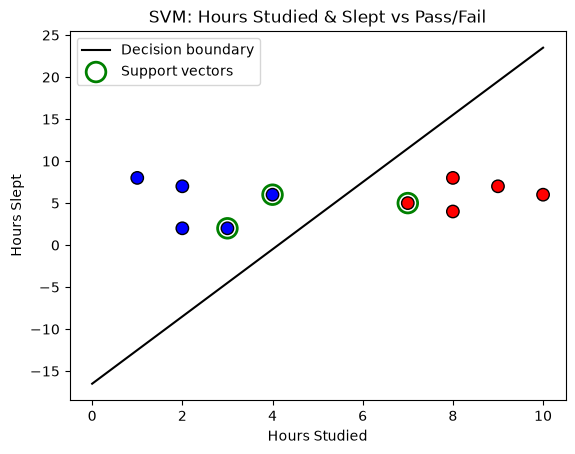

In [7]:
x_range = np.linspace(0, 10, 100)
boundary = -(w[0]*x_range + b) / w[1]

plt.scatter(hours_studied, hours_slept, c=passed, cmap="bwr", edgecolors="k", s=80)
plt.plot(x_range, boundary, color="black", label="Decision boundary")
plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
            s=200, facecolors="none", edgecolors="green", linewidths=2, label="Support vectors")
plt.title("SVM: Hours Studied & Slept vs Pass/Fail")
plt.xlabel("Hours Studied")
plt.ylabel("Hours Slept")
plt.legend()
plt.savefig("../visuals/svm_manual.png")
plt.show()

Let's map this to the actual math behind the boundary line and margin.

**Step 1 - the decision function**
SVM's boundary is defined by:
$$f(x) = w_1x_1 + w_2x_2 + b$$
With your values: $f(x) = 0.6154 \cdot \text{hours\_studied} + (-0.1538) \cdot \text{hours\_slept} + (-2.5384)$

**Step 2 - what "weights" mean here**
`w = [0.6154, -0.1538]` - `hours_studied` has a **positive** weight (more studying pushes toward "pass"), `hours_slept` has a small **negative** weight (in this toy dataset, more sleep slightly pushes toward "fail" - an artifact of how the manual numbers were picked, not a real-world claim). The magnitude also tells you which feature matters more to the boundary: `hours_studied` (0.6154) dominates over `hours_slept` (0.1538) - roughly 4x more influence.

**Step 3 - verifying the 3 support vectors by hand**
Plugging each support vector into $f(x)$:

$(3, 2)$: $0.6154(3) + (-0.1538)(2) - 2.5384 = 1.846 - 0.308 - 2.538 = -1.00$

$(4, 6)$: $0.6154(4) + (-0.1538)(6) - 2.5384 = 2.462 - 0.923 - 2.538 = -1.00$

$(7, 5)$: $0.6154(7) + (-0.1538)(5) - 2.5384 = 4.308 - 0.769 - 2.538 = +1.00$

**This is the actual mathematical definition of a support vector:** points where $f(x) = \pm1$ exactly - sitting precisely on the edge of the margin, not just anywhere near the boundary. Every other point in your dataset gives $|f(x)| > 1$, meaning it's safely on its correct side, outside the margin zone.

**Step 4 - the boundary itself**
The decision boundary is where $f(x) = 0$ exactly (not ±1) - that's the black line plotted, sitting exactly halfway between the two support-vector groups.

**Step 5 - the margin width (how wide that gap actually is)**
$$\text{Margin} = \frac{2}{\|w\|} = \frac{2}{\sqrt{w_1^2+w_2^2}} = \frac{2}{\sqrt{0.6154^2+(-0.1538)^2}} = \frac{2}{\sqrt{0.3787+0.0237}} = \frac{2}{0.6343} \approx 3.15$$

This 3.15 is the actual geometric width of the "buffer zone" between the two classes - the thing SVM was maximizing during training.

**Step 6 - reading the chart against this**
The two blue points circled green, $(3,2)$ and $(4,6)$, sit exactly on the $f(x)=-1$ edge; the red point circled green, $(7,5)$, sits exactly on the $f(x)=+1$ edge. Every other point (uncircled) is further from the line than these three — confirming visually that only these 3 points actually "support" (define) where the boundary sits; if you removed any *other* point and retrained, the boundary wouldn't move at all.



## SVM - Example 2: real dataset (Breast Cancer Wisconsin, built into sklearn)

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


In [9]:
data = load_breast_cancer(as_frame=True)

In [12]:
X = data.data
y = data.target   # 0=malignant, 1=benign

In [13]:
print(X.head())
print(y.value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# scaling is required for SVM - distance-based algorithm
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = SVC(kernel="rbf", probability=True, random_state=42)
model.fit(X_train_scaled, y_train)


/home/vscode/.local/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [17]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  2]
 [ 0 71]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC: 0.99737962659679


the result - 98.2% accuracy with only 2 total misclassifications out of 114. Let's break down what actually produced this.

**Confusion Matrix breakdown:**
```
                  Predicted:0(malignant)  Predicted:1(benign)
Actual:0(malignant)      41                    2
Actual:1(benign)          0                   71
```
- **41** correctly caught malignant cases
- **2** malignant cases wrongly predicted as benign (false negatives - the medically dangerous error type)
- **0** benign cases wrongly flagged as malignant (zero false positives!)
- **71** correctly caught benign cases

**Why this is genuinely so much stronger than the Telco churn result:** two structural reasons -

**Reason 1 - this dataset is far more separable.** Breast Cancer Wisconsin has 30 carefully engineered numeric features (cell radius, texture, smoothness, etc.) that were specifically measured *because* they're strong predictors of malignancy - this is fundamentally cleaner signal than 3 loosely related customer behavior columns.

**Reason 2 - proper scaling was applied this time.** `StandardScaler` was used before fitting - every feature contributes to the distance/margin calculation fairly, rather than being dominated by whichever feature happens to have larger raw numbers. This was skipped in the earlier Logistic Regression example, and its absence there was one of the flagged fallbacks.

**Recall breakdown, mathematically:**
$$\text{Recall (class 0, malignant)} = \frac{TP}{TP+FN} = \frac{41}{41+2} = 0.9535$$
Matches the 0.95 printed. This means 95% of actual malignant cases were caught - only 2 slipped through. In a medical context, this is the number that matters most (a missed malignant case is far costlier than an unnecessary follow-up test).

$$\text{Recall (class 1, benign)} = \frac{71}{71+0} = 1.00$$
Perfect - every actual benign case was correctly identified, zero false alarms.

**AUC = 0.997** - near-perfect class separation. Recall this means: if you randomly picked one malignant and one benign case, the model would correctly rank the malignant one as higher-risk 99.7% of the time — essentially as close to flawless discrimination as you'll see on real data.

**Why the `rbf` kernel likely helped here too:** unlike Example 1's simple linear kernel, `rbf` (radial basis function) can draw curved, more flexible boundaries - appropriate given 30 real-world biological features likely interact in non-linear ways that a straight line couldn't capture as cleanly.

**Honest contrast worth writing down as insight:** compare this AUC (0.997) against Logistic Regression's Telco AUC (0.80) - the difference isn't really about which *algorithm* is better in general, it's about **data quality and feature relevance**. This dataset's features were purpose-built for this exact prediction task; Telco's 3 raw numeric columns were a much weaker starting point. A key lesson for the churn project eventually: better/more relevant features (including the categorical ones not yet used) would likely lift Telco's ceiling more than switching algorithms alone.

